# TRABAJO SEMANAL 5: ESTIMACIÓN ESPECTRAL
## ALUMNA: Maylen Monterde

El objetivo de este trabajo es estimar la densidad espectral de potencia (PSD) de señales de distinto origen (un electrocardiograma, una pletismografía y tres registros de audio) mediante el método de Welch, y a partir de ella estimar el ancho de banda de cada una para poder compararlas.

### Periodograma:

La PSD describe cómo se distribuye la potencia de una señal en función de la frecuencia. Como en la práctica solo se tiene un registro finito de $N$ muestras $x[n]$, con $n = 0, 1, \dots, N-1$, la PSD no puede calcularse exactamente y por eso debe estimarse. El estimador más directo es el periodograma, definido a partir de la DFT de la señal:

$$X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-j\frac{2\pi k n}{N}}, \qquad P[k] = \frac{1}{N}\,\left|X[k]\right|^2$$

Este estimador es asintóticamente insesgado, pero su varianza no disminuye al aumentar $N$: por más muestras que se tengan, la estimación sigue siendo muy ruidosa. Es decir, el periodograma no es un estimador consistente.

### Método de Welch:

Para reducir la varianza, el método de Welch divide la señal en $K$ segmentos de longitud $L$, generalmente solapados en un 50 %, multiplica cada segmento por una ventana $w[n]$ y promedia los periodogramas resultantes:

$$I_i(\omega) = \frac{1}{L\,U}\left|\sum_{n=0}^{L-1} x_i[n]\, w[n]\, e^{-j\omega n}\right|^2, \qquad U = \frac{1}{L}\sum_{n=0}^{L-1} |w[n]|^2$$

$$\hat{S}^{W}_X(\omega) = \frac{1}{K}\sum_{i=1}^{K} I_i(\omega)$$

donde $U$ es la constante que compensa la pérdida de potencia introducida por la ventana. En este trabajo se utilizó una ventana de Hamming, que presenta una buena separación entre el lóbulo principal y los secundarios.

Al promediar $K$ periodogramas, la varianza disminuye aproximadamente en un factor $1/K$. El costo es una peor resolución espectral, que pasa de $\Delta f = f_s/N$ en el periodograma a $\Delta f = f_s/L$ en Welch. Por lo tanto, existe un compromiso: segmentos largos (pocos promedios) dan buena resolución pero una curva ruidosa, mientras que segmentos cortos (muchos promedios) dan una curva suave pero con picos ensanchados. En este caso se consideró $L = N/k$ y se estudió el efecto de variar $k$.

Existe también el método de Blackman-Tukey, que estima la autocorrelación, la ventanea en un número acotado de retardos y luego calcula su transformada de Fourier. En este trabajo no se utilizó.

### CONSIGNA:

Se analizaron cinco registros: un electrocardiograma (ECG, $f_s = 1000$ Hz), una pletismografía (PPG, $f_s = 400$ Hz) y tres registros de audio ("la cucaracha", "silbido" y "prueba psd", $f_s = 48000$ Hz). Para cada uno se presenta la señal en el tiempo, la PSD estimada para distintos valores de $k$ y, finalmente, una tabla comparativa de anchos de banda.

### RESOLUCIÓN:
1- Grafico las distintas señales en el dominio del tiempo y luego su estimación de Welch en el dominio de la frecuencia:

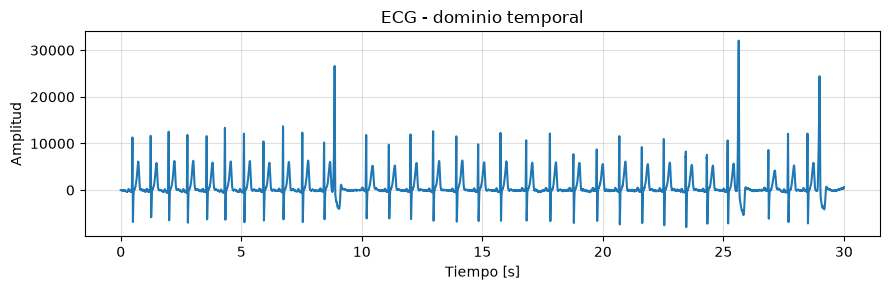

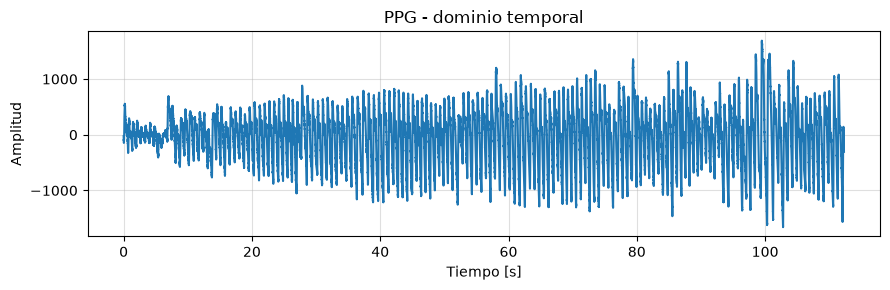

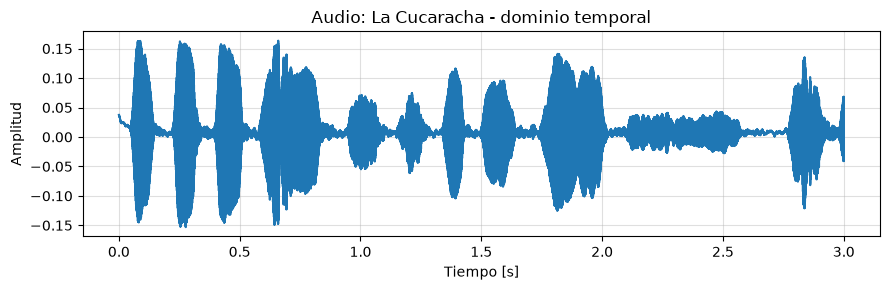

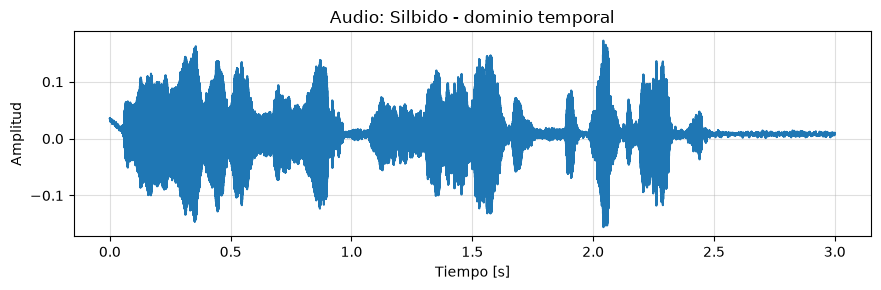

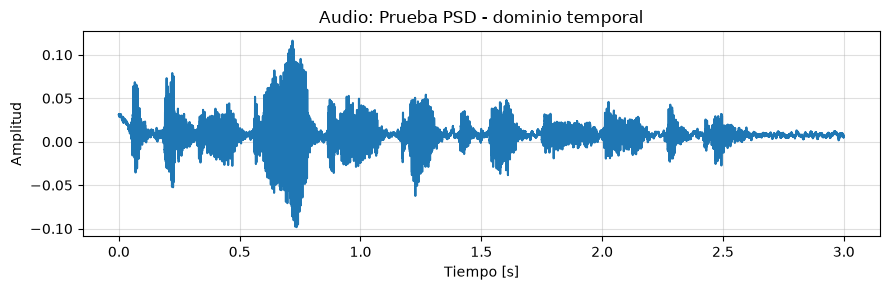

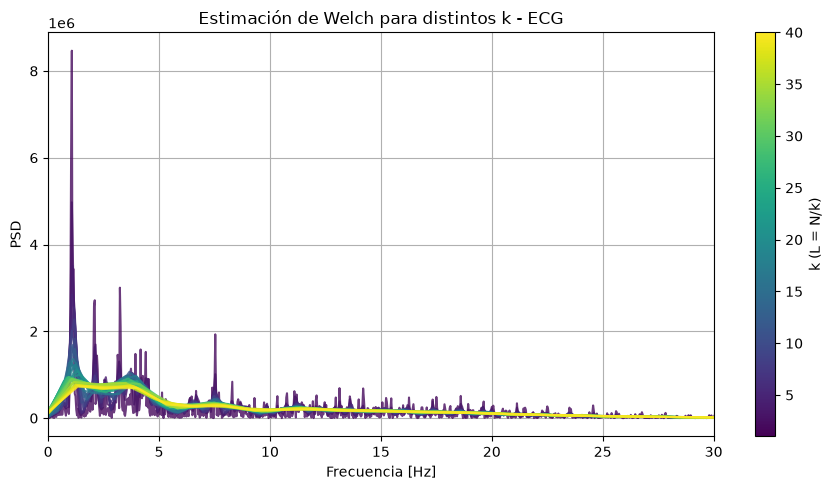

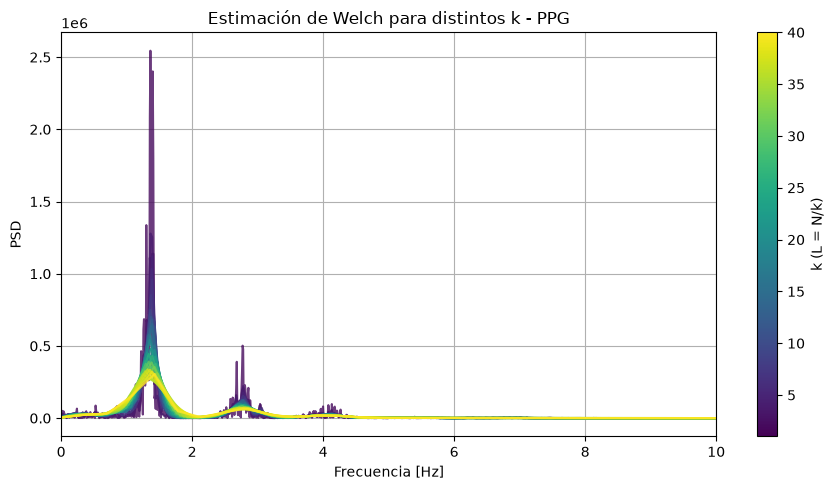

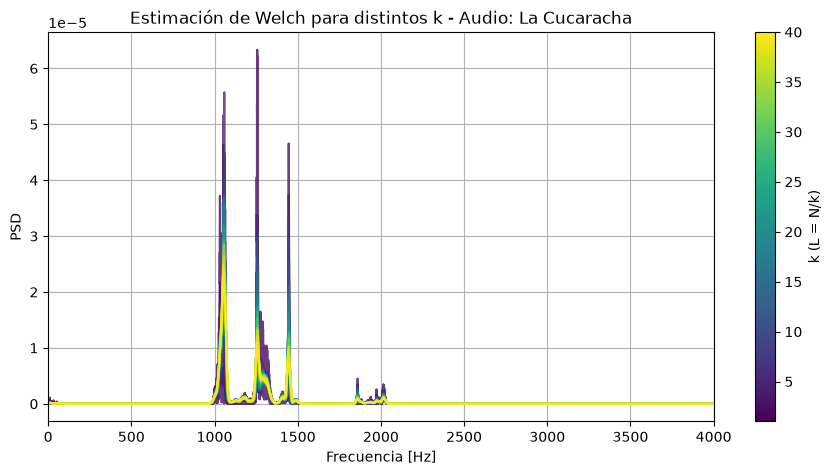

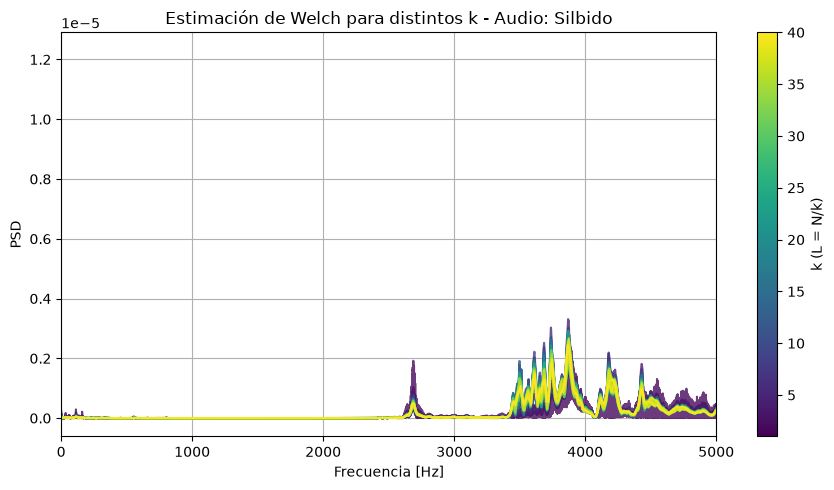

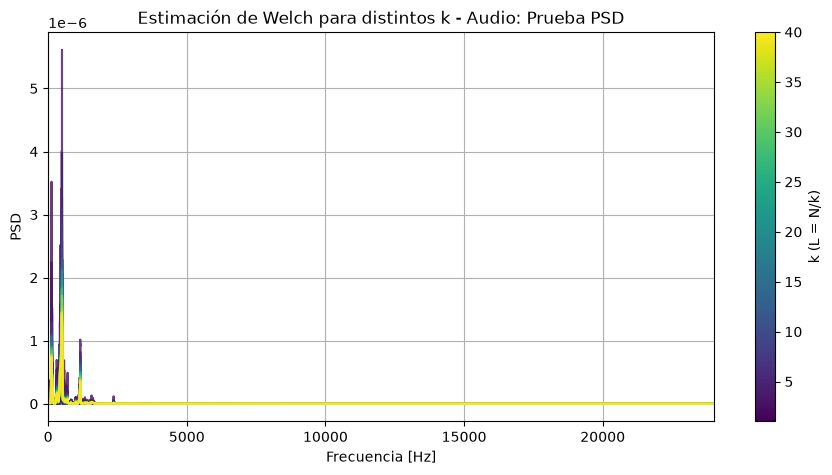

In [7]:
## TS5 - ESTIMACIÓN ESPECTRAL
#%% Librerías:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal
from scipy.io import wavfile

#%% Carga de señales:
fs_ecg = 1000  
fs_ppg = 400    

ecg = np.load('ecg_sin_ruido.npy').flatten()
ppg = np.load('ppg_sin_ruido.npy').flatten()

fs_a1, a1 = wavfile.read('la cucaracha.wav')
fs_a2, a2 = wavfile.read('silbido.wav')
fs_a3, a3 = wavfile.read('prueba psd.wav')

# nombre: (señal, fs, xlim para graficar la PSD)
senales = {
    'ECG':                 (ecg, fs_ecg, (0, 30)),
    'PPG':                 (ppg, fs_ppg, (0, 10)),
    'Audio: La Cucaracha': (a1, fs_a1, (0, 4000)),
    'Audio: Silbido':      (a2, fs_a2, (0, 5000)),
    'Audio: Prueba PSD':   (a3, fs_a3, (0, fs_a3 / 2)),
}


#%% Señales en el tiempo:
for nombre, (x, fs, _) in senales.items():
    t = np.arange(len(x)) / fs
    plt.figure(figsize=(9, 3))
    plt.plot(t, x)
    plt.title(f'{nombre} - dominio temporal')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

#%% Barrido en k:
def barrido_welch(x, fs, titulo, xlim=None, k_max=40):
    N = len(x)
    cmap = plt.colormaps['viridis']

    plt.figure(figsize=(9, 5))
    for k in range(1, k_max + 1):
        L = N // k
        if L < 8:
            continue
        f, Pxx = signal.welch(x, fs=fs, window='hamming', nperseg=L,
                              detrend='constant', scaling='density')
        plt.plot(f, Pxx, color=cmap(k / k_max), alpha=0.8)

    plt.title(f'Estimación de Welch para distintos k - {titulo}')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('PSD')
    if xlim is not None:
        plt.xlim(*xlim)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=k_max))
    sm.set_array([])
    plt.colorbar(sm, ax=plt.gca(), label='k (L = N/k)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


for nombre, (x, fs, xlim) in senales.items():
    barrido_welch(x, fs, nombre, xlim)

**OBSERVACIONES**:
En los gráficos de Welch se observa el compromiso entre varianza y resolución espectral. Para k chico (segmentos largos, pocos promedios) la resolución es fina y los picos se distinguen bien, pero la curva es ruidosa por la alta varianza del estimador. A medida que k aumenta (curva amarilla) la varianza disminuye y la curva se suaviza, pero la resolución empeora (Δf = fs/L crece) y los picos cercanos se ensanchan y se fusionan. Ninguno de los extremos es adecuado. El valor de k debe elegirse según lo que se quiera observar en cada señal.

In [8]:
#%% Ancho de banda

def ancho_de_banda(x, fs, pct=0.99):
    L = min(len(x), int(2 * fs))
    f, Pxx = signal.welch(x, fs=fs, window='hamming', nperseg=L, detrend='constant')

    acum = np.cumsum(Pxx) / np.sum(Pxx)
    cola = (1 - pct) / 2
    f_min = f[np.searchsorted(acum, cola)]
    f_max = f[np.searchsorted(acum, 1 - cola)]

    idx = np.where(Pxx >= Pxx.max() / 2)[0]
    bw_3db = f[idx[-1]] - f[idx[0]]

    return f_min, f_max, f_max - f_min, bw_3db


filas = []
for nombre, (x, fs, _) in senales.items():
    f_min, f_max, bw99, bw3 = ancho_de_banda(x, fs)
    filas.append({'Señal': nombre, 'Fs (Hz)': fs,
                  'f_min_99 (Hz)': round(f_min, 2),
                  'f_max_99 (Hz)': round(f_max, 2),
                  'BW 99% (Hz)': round(bw99, 2),
                  'BW -3dB (Hz)': round(bw3, 2)})

tabla_bw = pd.DataFrame(filas)
print('\n--- TABLA DE ESTIMACIÓN DE ANCHO DE BANDA ---')
print(tabla_bw.to_string(index=False))
tabla_bw


--- TABLA DE ESTIMACIÓN DE ANCHO DE BANDA ---
              Señal  Fs (Hz)  f_min_99 (Hz)  f_max_99 (Hz)  BW 99% (Hz)  BW -3dB (Hz)
                ECG     1000            0.5           36.0         35.5           3.0
                PPG      400            0.0            7.0          7.0           0.5
Audio: La Cucaracha    48000          992.5         2025.0       1032.5         194.5
     Audio: Silbido    48000         2566.5         6764.5       4198.0          56.0
  Audio: Prueba PSD    48000           19.5         3052.5       3033.0         385.5


,Señal,Fs (Hz),f_min_99 (Hz),f_max_99 (Hz),BW 99% (Hz),BW -3dB (Hz)
0,ECG,1000,0.5,36.0,35.5,3.0
1,PPG,400,0.0,7.0,7.0,0.5
2,Audio: La Cucaracha,48000,992.5,2025.0,1032.5,194.5
3,Audio: Silbido,48000,2566.5,6764.5,4198.0,56.0
4,Audio: Prueba PSD,48000,19.5,3052.5,3033.0,385.5


Las señales fisiológicas tienen un ancho de banda mucho menor que las de audio. El ECG ocupa unos 35,5 Hz (0,5 a 36 Hz) y la PPG unos 7 Hz (0 a 7 Hz), mientras que los audios tienen anchos de banda de entre ≈1000 Hz (la cucaracha) y ≈4200 Hz (el silbido). Esto es coherente con su origen: las señales fisiológicas están gobernadas por el ritmo cardíaco (≈1 Hz) y sus armónicos, mientras que el audio es una señal acústica con componentes de miles de Hz.

Los dos criterios dan resultados muy distintos, porque miden cosas diferentes. El de la banda del 99 % indica dónde está casi toda la potencia, incluidas las colas de baja amplitud. El de −3 dB solo mide la separación entre las frecuencias extremas donde la PSD supera la mitad del pico máximo, por lo que depende de cuántos picos alcancen ese nivel y de cuán separados estén. Por eso da valores muy chicos en el ECG (3 Hz), el PPG (0,5 Hz) y el silbido (56 Hz), aunque sus bandas del 99 % sean mucho mayores. Para describir el contenido espectral total de la señal resulta más representativo el criterio del 99 %.

## Conclusiones
En este trabajo se pudo observar el balance entre sesgo y varianza del estimador de Welch, cuando se busca mejorar uno se 'sacrifica' el otro a medida que cambio la cantidad de fragmentos que se realice. Si considero un k grande con el método de Welch obtengo una menor varianza pero pierdo resolución espectral, caso contrario si consideraría un valor de k chico.